
# CNN with Layer Visualizations (PyTorch)

This notebook trains a small CNN on the SVHN dataset (RGB, 32×32) and visualizes:
- Input image and prediction
- Feature maps after `conv1` and `conv2` 
- Learned filters of the first conv layer


In [82]:

import os, random, math
import numpy as np
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils as vutils
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


In [83]:

# Data loading and normalization for SVHN
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728],
                         std=[0.1980, 0.2010, 0.1970])
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728],
                         std=[0.1980, 0.2010, 0.1970])
])

train_set = datasets.SVHN(root='./data', split='train', download=True, transform=transform_train)
valid_set  = datasets.SVHN(root='./data', split='test',  download=True, transform=transform_test)

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
valid_loader  = DataLoader(valid_set,  batch_size=batch_size, shuffle=False, num_workers=0)
len(train_set), len(valid_set)

(73257, 26032)

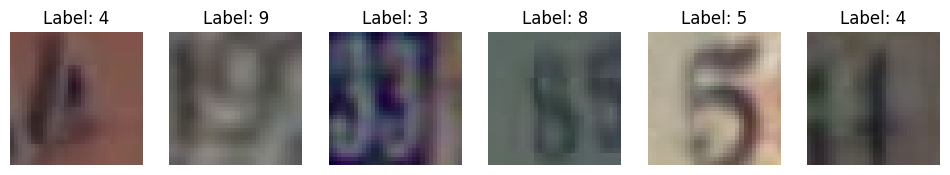

In [84]:
# Visualize some data
dataiter = iter(train_loader)
images, labels = dataiter.__next__()
fig, axes = plt.subplots(1, 6, figsize=(12,2))
for i in range(6):  
    img = images[i].numpy().transpose((1, 2, 0))
    img = img * np.array([0.1980, 0.2010, 0.1970]) + np.array([0.4377, 0.4438, 0.4728])  # unnormalize
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')

In [85]:
# Define a small CNN
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2,2)
        self.fc1   = nn.Linear(16*8*8, 64)
        self.fc2   = nn.Linear(64, 10)
    def forward(self, x, return_feats=False):
        x = F.relu(self.conv1(x)); f1 = self.pool1(x)
        x = F.relu(self.conv2(f1)); f2 = self.pool2(x)
        x = torch.flatten(f2, 1); x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        if return_feats: return logits, f1, f2
        return logits

# Initialize model, loss function, and optimizer
model = SmallCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


In [86]:
# Training and evaluation loop
def evaluate(model, loader, device):
    model.eval(); correct=total=0; loss_sum=0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device) 
            logits = model(images)
            loss = criterion(logits, labels)
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            loss_sum += loss.item() * labels.size(0)
    return correct/max(1,total), loss_sum/max(1,total)

epochs = 5
train_hist, valid_hist = [], []
for epoch in range(1, epochs+1):
    model.train(); run_loss=0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward(); optimizer.step()
        run_loss += loss.item()
    train_acc, train_loss = evaluate(model, train_loader, device)
    valid_acc, valid_loss   = evaluate(model, valid_loader, device)
    train_hist.append((train_loss, train_acc)); valid_hist.append((valid_loss, valid_acc))
    print(f"Epoch {epoch:02d}/{epochs} | Train loss {train_loss:.4f}, accuracy {train_acc*100:.2f}% | "
          f"Test loss {valid_loss:.4f}, accuracy {valid_acc*100:.2f}%")


Epoch 01/5 | Train loss 0.6179, accuracy 82.42% | Test loss 0.7045, accuracy 80.24%
Epoch 02/5 | Train loss 0.5047, accuracy 85.72% | Test loss 0.6140, accuracy 82.76%
Epoch 03/5 | Train loss 0.4448, accuracy 87.38% | Test loss 0.5575, accuracy 84.37%
Epoch 04/5 | Train loss 0.3937, accuracy 88.78% | Test loss 0.5268, accuracy 85.21%
Epoch 05/5 | Train loss 0.3728, accuracy 89.11% | Test loss 0.5103, accuracy 85.62%


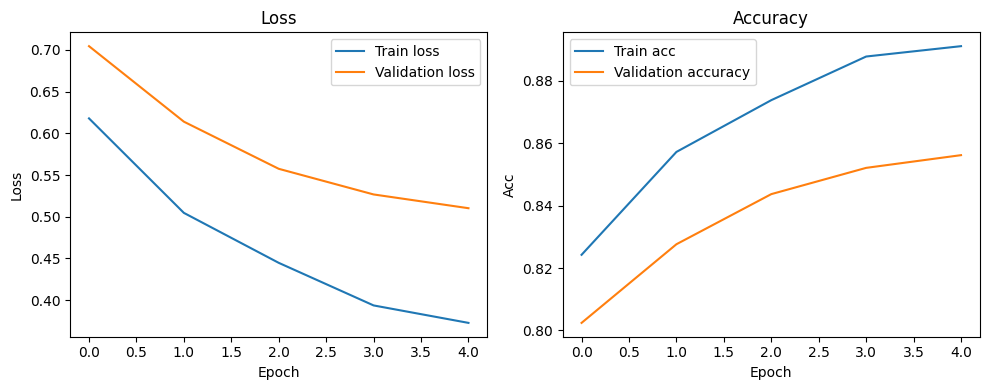

In [87]:

# Plot training loss and accuracy curves
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot([t[0] for t in train_hist], label='Train loss')
plt.plot([t[0] for t in valid_hist],  label='Validation loss')
plt.legend(); plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.subplot(1,2,2)
plt.plot([t[1] for t in train_hist], label='Train acc')
plt.plot([t[1] for t in valid_hist],  label='Validation accuracy')
plt.legend(); plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc")
plt.tight_layout(); plt.show()


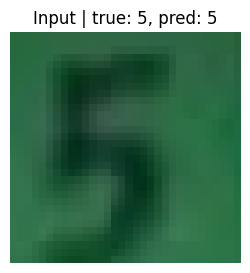

(torch.Size([1, 8, 16, 16]), torch.Size([1, 16, 8, 8]))

In [88]:

# One test image + feature maps
model.eval()
images, labels = next(iter(valid_loader))
img = images[0:1].to(device); label = labels[0].item()
with torch.no_grad():
    logits, f1, f2 = model(img, return_feats=True)
    pred = logits.argmax(1).item()

# Denormalize for display
mean = torch.tensor([0.4377, 0.4438, 0.4728], device=device).view(1,3,1,1)
std  = torch.tensor([0.1980, 0.2010, 0.1970], device=device).view(1,3,1,1)
img_denorm = img * std + mean
img_np = img_denorm[0].detach().cpu().permute(1,2,0).numpy(); img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(3,3)); plt.imshow(img_np); plt.title(f"Input | true: {label}, pred: {pred}")
plt.axis('off'); plt.show()

f1.shape, f2.shape


In [89]:

# Visualization helpers
import math
def plot_feature_maps_grid(feat, title_prefix="Feature map", max_maps=16):
    feat_np = feat[0].detach().cpu().numpy()
    C, H, W = feat_np.shape; n = min(C, max_maps)
    cols = int(math.sqrt(n) + 0.999); rows = int(math.ceil(n / cols))
    plt.figure(figsize=(2*cols, 2*rows))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        fm = feat_np[i]; fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        plt.imshow(fm, cmap='gray'); plt.title(f"{title_prefix} {i}"); plt.axis('off')
    plt.tight_layout(); plt.show()

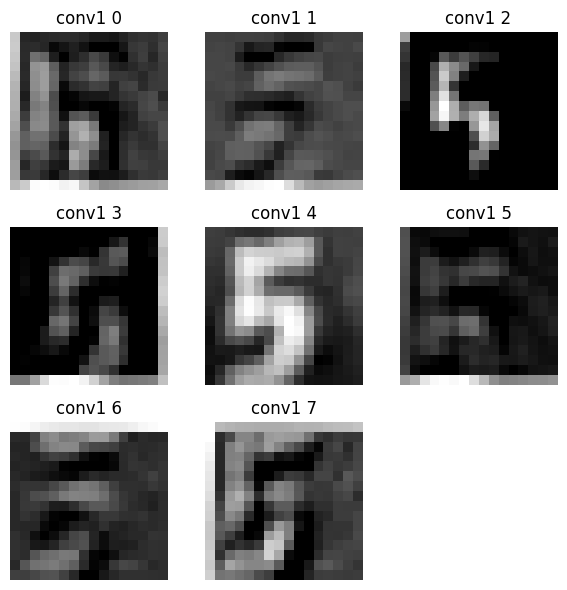

In [90]:

# conv1 maps — grid
plot_feature_maps_grid(f1, title_prefix="conv1", max_maps=8)


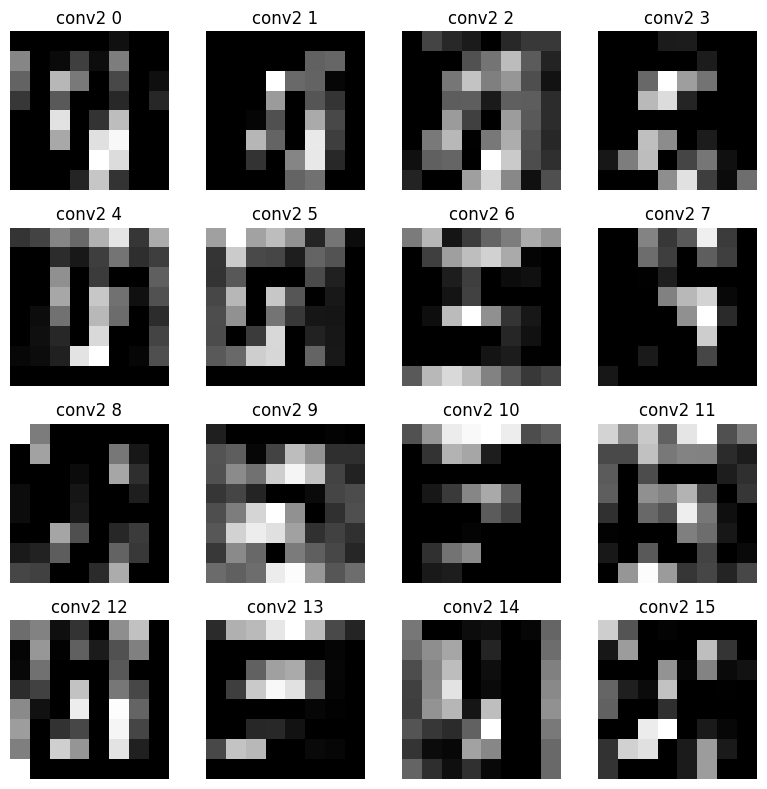

In [91]:

# conv2 maps — grid
plot_feature_maps_grid(f2, title_prefix="conv2", max_maps=16)


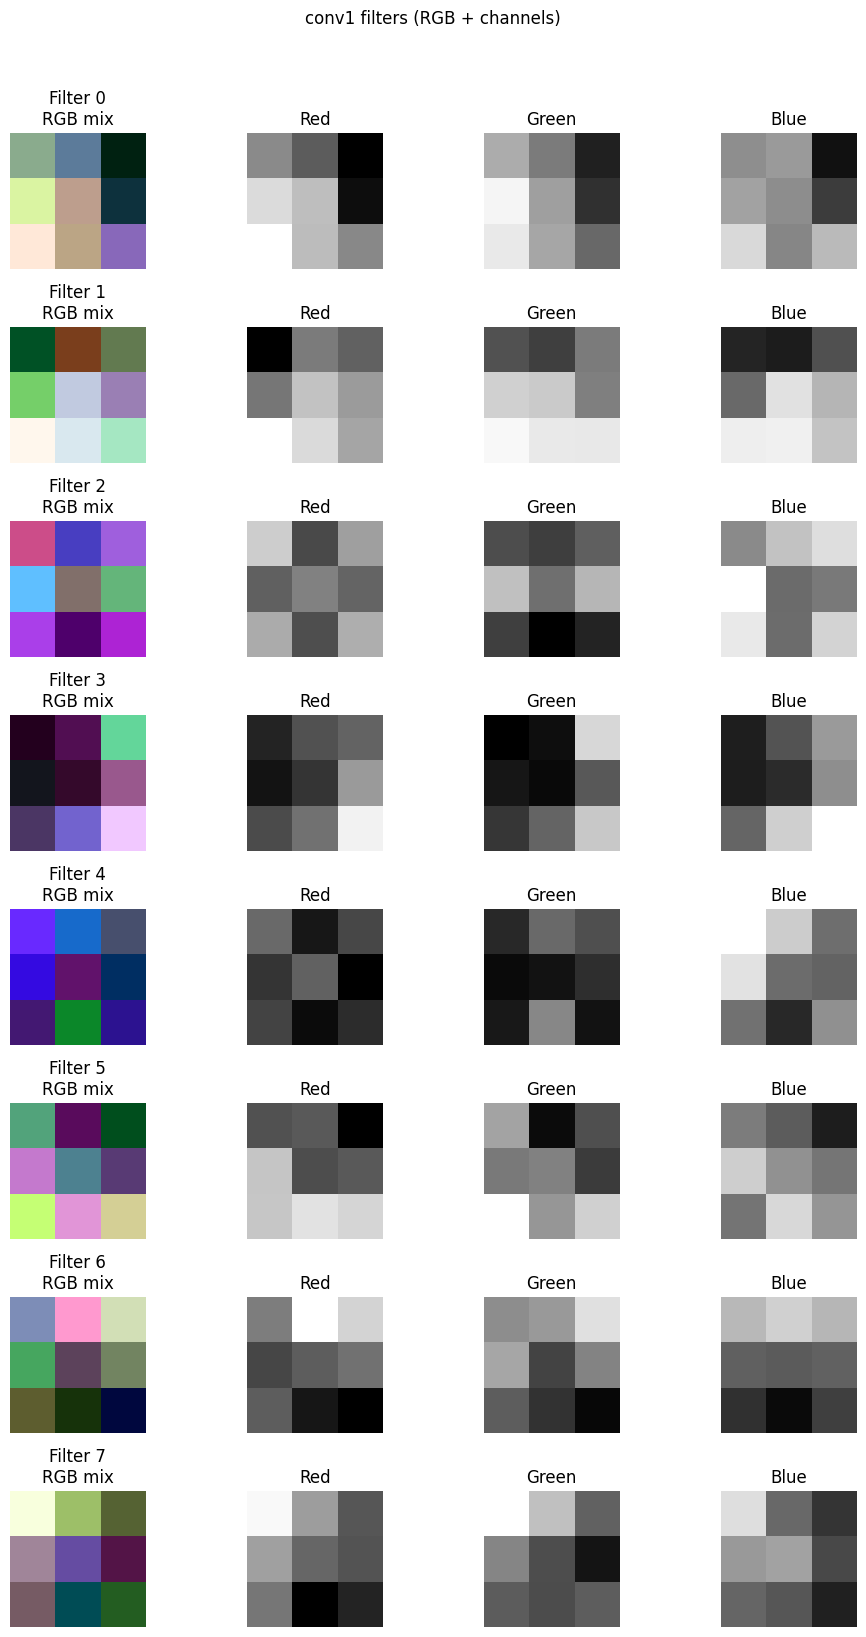

In [92]:
# Visualize first-layer conv filters by channel (R/G/B separately)

w = model.conv1.weight.detach().cpu().numpy()  # [n_filters, 3, 3, 3]
n_filters = w.shape[0]
cols = 4   # 1x RGB + 3x channels
rows = n_filters

plt.figure(figsize=(2.5 * cols, 2 * rows))

for i in range(n_filters):
    k = w[i]  # [3,3,3]
    k_min, k_max = k.min(), k.max()
    k_norm = (k - k_min) / (k_max - k_min + 1e-8)
    k_rgb = np.transpose(k_norm, (1, 2, 0))

    # Combined RGB
    plt.subplot(rows, cols, i * cols + 1)
    plt.imshow(k_rgb)
    plt.title(f"Filter {i}\nRGB mix")
    plt.axis("off")

    # Individual channels
    for c, name in enumerate(["Red", "Green", "Blue"], start=1):
        plt.subplot(rows, cols, i * cols + c + 1)
        plt.imshow(k_norm[c-1], cmap="gray", vmin=0, vmax=1)
        plt.title(name)
        plt.axis("off")

plt.suptitle("conv1 filters (RGB + channels)", y=1.02)
plt.tight_layout()
plt.show()


In [121]:
def visualize_cnn_features(model, img, device='cpu', n_maps=8, title='Input image'):
    """
    Apply a CNN to an input image and visualize the first-layer feature maps.

    Args:
        model: CNN model that returns (output, feat1, feat2, ...) when called with return_feats=True
        img: torch.Tensor or np.ndarray, shape (3,H,W) or (1,3,H,W)
        device: 'cpu' or 'cuda'
        n_maps: number of feature maps to display
        title: title for input image plot
    """

    # Ensure shape (1,3,H,W)
    if img.ndim == 3:
        img = img.unsqueeze(0)
    img = img.to(device, dtype=torch.float32)

    # Forward pass
    with torch.no_grad():
        outputs = model(img, return_feats=True)
        if isinstance(outputs, tuple):
            _, f1, f2 = outputs
        else:
            raise ValueError("Model must return (out, feat1, feat2, ...) with return_feats=True")

    # === Plot input image ===
    fig, ax = plt.subplots(figsize=(3,3))
    ax.imshow(img[0].permute(1,2,0).cpu(), vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1)
    fig.suptitle(f"Input image – {title}", fontsize=12)
    plt.show()

    # === Plot conv1 feature maps ===
    f1_np = f1[0].cpu().numpy()
    n_maps = min(n_maps, f1_np.shape[0])
    cols = 4
    rows = math.ceil(n_maps / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))

    # Flatten 2D axes array for easy indexing
    axes = axes.flatten()

    for i in range(n_maps):
        fm = f1_np[i]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        ax = axes[i]
        ax.imshow(fm, cmap='gray')
        ax.set_title(f"FM {i}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    # Turn off unused subplots
    for j in range(n_maps, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f"conv1 activations – {title}", fontsize=12)
    plt.tight_layout()
    plt.show()


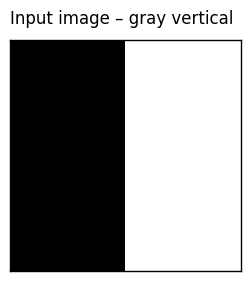

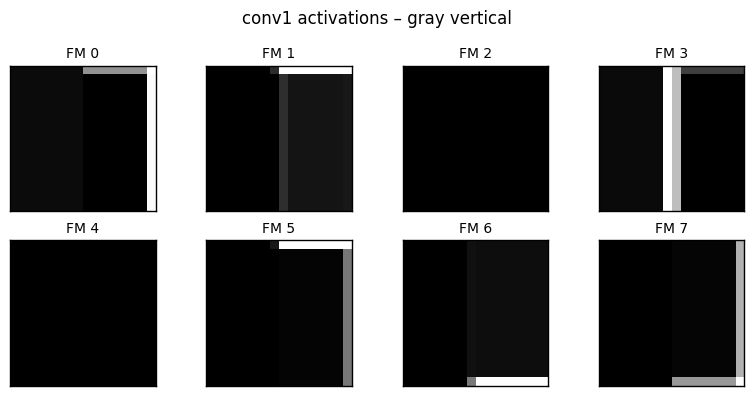

In [122]:
# Generate synthetic test patterns with sharp intensity or color transitions
size = 32
img = torch.zeros(3, size, size)
img[:, :, 32//2:] = 1.0
visualize_cnn_features(model, img, device=device, title='gray vertical')

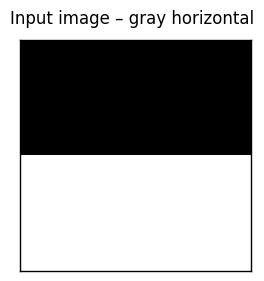

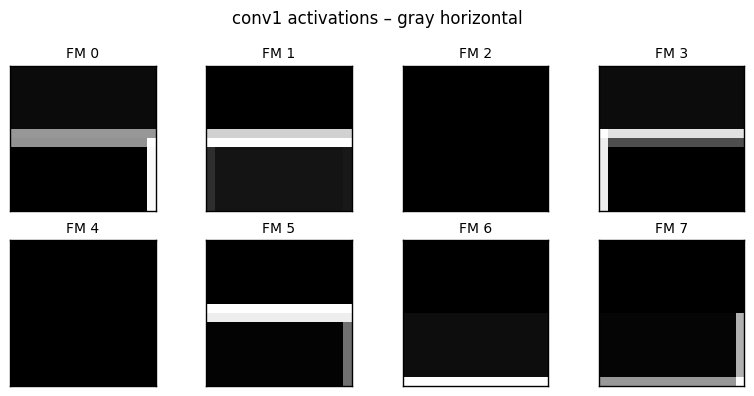

In [123]:
# Generate synthetic test patterns with sharp intensity or color transitions
img = torch.zeros(3, size, size)
img[:, size//2:, :] = 1.0
visualize_cnn_features(model, img, device=device, title='gray horizontal')

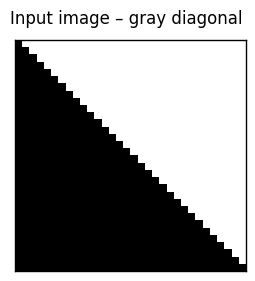

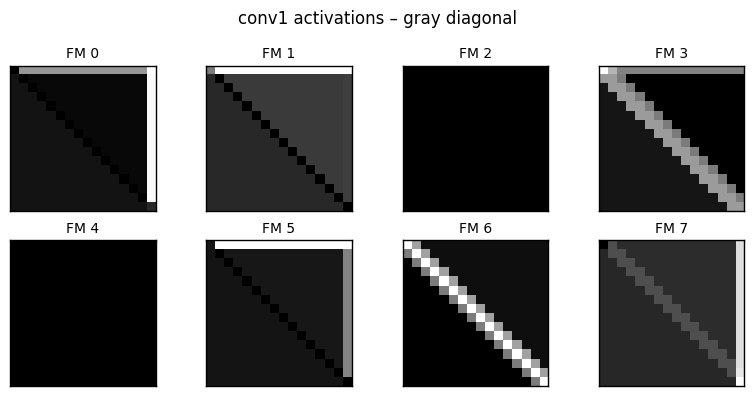

In [124]:
# Generate synthetic test patterns with sharp intensity or color transitions
img = torch.zeros(3, size, size)
for i in range(size):
    for j in range(size):
        if j > i:
            img[:, i, j] = 1.0
visualize_cnn_features(model, img, device=device, title='gray diagonal')

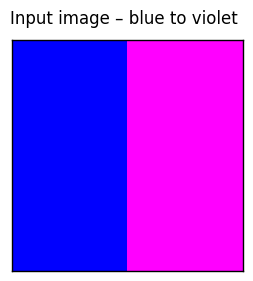

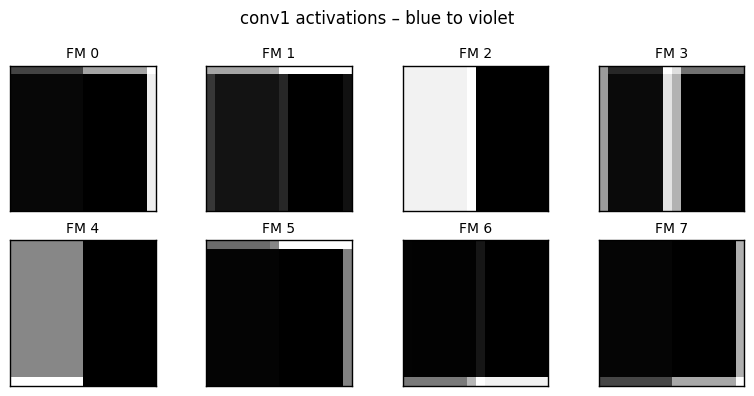

In [125]:
# Generate synthetic test patterns with sharp intensity or color transitions
img = torch.zeros(3, size, size)
img[2, :, :size//2] = 1.0            # blue
img[0, :, size//2:] = 1.0; img[2, :, size//2:] = 1.0  # violet
visualize_cnn_features(model, img, device=device, title='blue to violet')

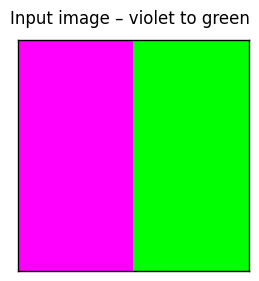

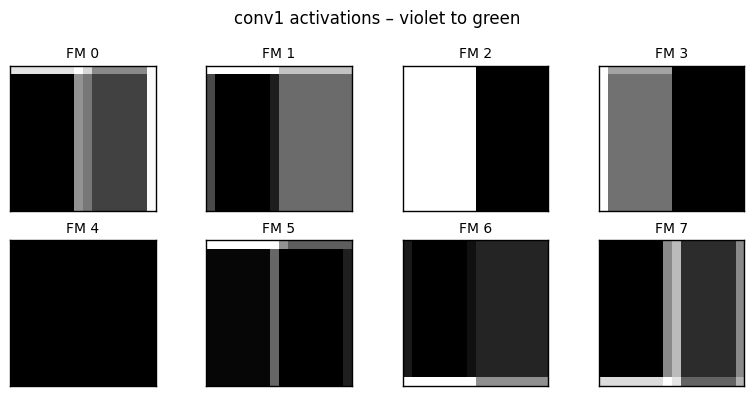

In [126]:
# Generate synthetic test patterns with sharp intensity or color transitions
img = torch.zeros(3, size, size)
img[0, :, :size//2] = 1.0; img[2, :, :size//2] = 1.0  # violet
img[1, :, size//2:] = 1.0                            # green
visualize_cnn_features(model, img, device=device, title='violet to green')

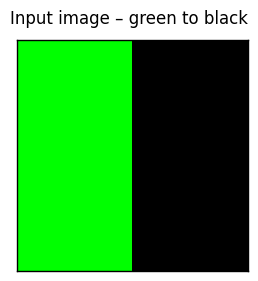

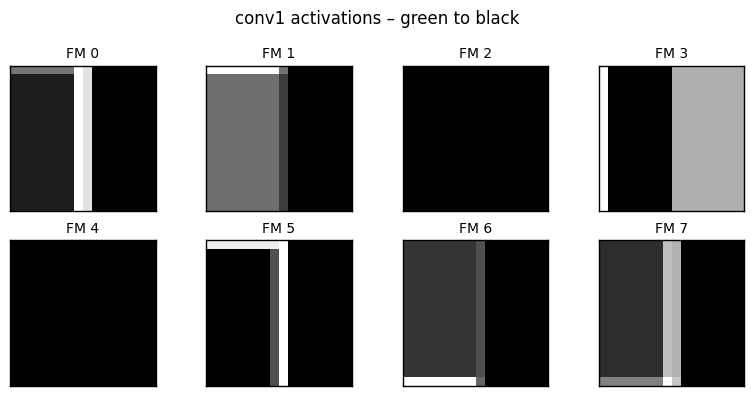

In [127]:
# Generate synthetic test patterns with sharp intensity or color transitions
img = torch.zeros(3, size, size)
img[1, :, :size//2] = 1.0
visualize_cnn_features(model, img, device=device, title='green to black')